In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from walmart_forecasting.data import load_merged_data, load_raw_data
from walmart_forecasting.paths import FIGURES_DIR
from walmart_forecasting.validation import competition_like_holdout

In [2]:
raw = load_raw_data()
data = load_merged_data()

features = raw.features
stores = raw.stores

train = data.train
test = data.test

In [3]:
datasets = {
    "train": train,
    "test": test,
    "features": features,
    "stores": stores,
}

overview = pd.DataFrame(
    {
        "rows": {
            name: len(frame)
            for name, frame in datasets.items()
        },
        "columns": {
            name: frame.shape[1]
            for name, frame in datasets.items()
        },
    }
)

overview

,rows,columns
train,421570,16
test,115064,15
features,8190,12
stores,45,3


In [4]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [5]:
test.head()

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


In [6]:
time_summary = pd.Series(
    {
        "train_start": train["Date"].min(),
        "train_end": train["Date"].max(),
        "test_start": test["Date"].min(),
        "test_end": test["Date"].max(),
        "train_unique_weeks": train["Date"].nunique(),
        "test_unique_weeks": test["Date"].nunique(),
        "stores": train["Store"].nunique(),
        "departments": train["Dept"].nunique(),
        "store_department_series": (
            train[["Store", "Dept"]]
            .drop_duplicates()
            .shape[0]
        ),
    }
)

time_summary

train_start                2010-02-05 00:00:00
train_end                  2012-10-26 00:00:00
test_start                 2012-11-02 00:00:00
test_end                   2013-07-26 00:00:00
train_unique_weeks                         143
test_unique_weeks                           39
stores                                      45
departments                                 81
store_department_series                   3331
dtype: object

In [7]:
split = competition_like_holdout(
    train_data=train,
    test_data=test,
)

print("Training period:")
print(split.train["Date"].min(), "to", split.train["Date"].max())

print("\nValidation period:")
print(split.validation_start, "to", split.validation_end)

print("\nValidation weeks:")
print(split.validation_weeks)

print("\nRows:")
print("Train:", len(split.train))
print("Validation:", len(split.validation))

Training period:
2010-02-05 00:00:00 to 2012-01-27 00:00:00

Validation period:
2012-02-03 00:00:00 to 2012-10-26 00:00:00

Validation weeks:
39

Rows:
Train: 305982
Validation: 115588


## Data integrity and missing values

In [8]:
key_columns = ["Store", "Dept", "Date"]

integrity_summary = pd.Series(
    {
        "train_duplicate_keys": train.duplicated(key_columns).sum(),
        "test_duplicate_keys": test.duplicated(key_columns).sum(),
        "train_missing_target": train["Weekly_Sales"].isna().sum(),
        "train_invalid_dates": train["Date"].isna().sum(),
        "test_invalid_dates": test["Date"].isna().sum(),
        "train_rows": len(train),
        "test_rows": len(test),
    }
)

integrity_summary

train_duplicate_keys         0
test_duplicate_keys          0
train_missing_target         0
train_invalid_dates          0
test_invalid_dates           0
train_rows              421570
test_rows               115064
dtype: int64

In [9]:
def missing_summary(dataframe: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame(
        {
            "missing_count": dataframe.isna().sum(),
            "missing_percent": dataframe.isna().mean() * 100,
            "dtype": dataframe.dtypes.astype(str),
        }
    )

    return result.sort_values(
        "missing_percent",
        ascending=False,
    )


train_missing = missing_summary(train)
test_missing = missing_summary(test)

train_missing

,missing_count,missing_percent,dtype
MarkDown2,310322,73.611025,float64
MarkDown4,286603,67.984676,float64
MarkDown3,284479,67.480845,float64
MarkDown1,270889,64.257181,float64
MarkDown5,270138,64.079038,float64
Store,0,0.000000,int64
Date,0,0.000000,datetime64[ns]
Dept,0,0.000000,int64
Fuel_Price,0,0.000000,float64
Temperature,0,0.000000,float64


In [10]:
test_missing

,missing_count,missing_percent,dtype
Unemployment,38162,33.165890,float64
CPI,38162,33.165890,float64
MarkDown2,28627,24.879198,float64
MarkDown4,12888,11.200723,float64
MarkDown3,9829,8.542203,float64
MarkDown1,149,0.129493,float64
Dept,0,0.000000,int64
Fuel_Price,0,0.000000,float64
Temperature,0,0.000000,float64
IsHoliday,0,0.000000,bool


In [11]:
missing_comparison = pd.DataFrame(
    {
        "Train": train_missing["missing_percent"],
        "Test": test_missing["missing_percent"],
    }
).fillna(0)

missing_comparison = missing_comparison[
    missing_comparison.max(axis=1) > 0
]

missing_comparison = missing_comparison.sort_values(
    by=["Train", "Test"],
    ascending=True,
)

missing_comparison

,Train,Test
CPI,0.000000,33.165890
Unemployment,0.000000,33.165890
MarkDown5,64.079038,0.000000
MarkDown1,64.257181,0.129493
MarkDown3,67.480845,8.542203
MarkDown4,67.984676,11.200723
MarkDown2,73.611025,24.879198


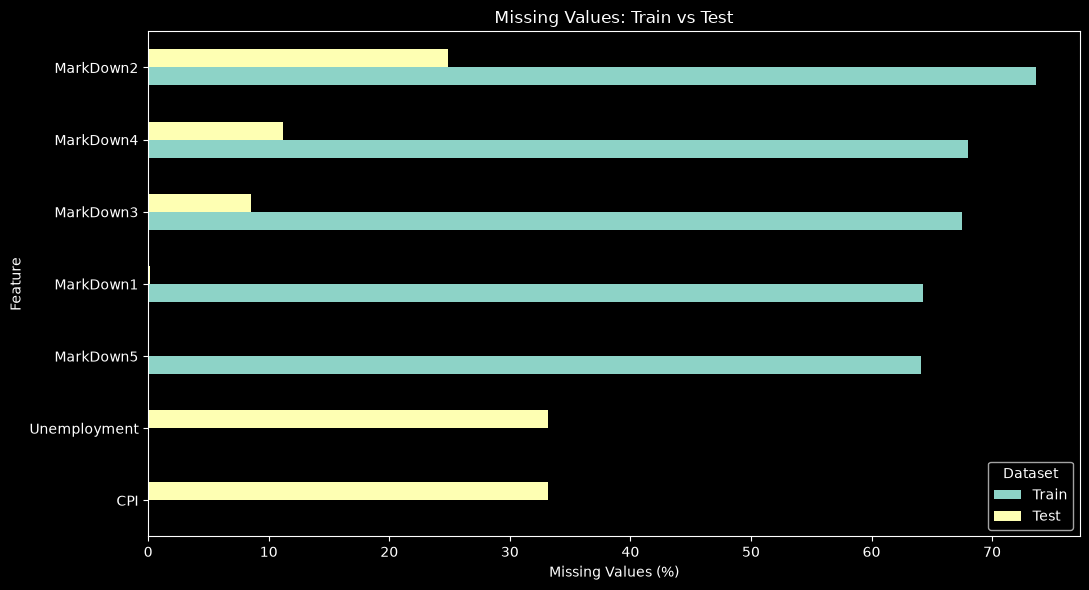

In [12]:
figure, axis = plt.subplots(figsize=(11, 6))

missing_comparison.plot(
    kind="barh",
    ax=axis,
)

axis.set_title("Missing Values: Train vs Test")
axis.set_xlabel("Missing Values (%)")
axis.set_ylabel("Feature")
axis.legend(title="Dataset")

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "train_test_missingness_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Feature availability at Store–Date level


In [13]:
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

economic_columns = [
    "CPI",
    "Unemployment",
]


def get_store_date_data(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    return (
        dataframe[["Store", "Date", *columns]]
        .drop_duplicates(["Store", "Date"])
        .sort_values(["Date", "Store"])
        .reset_index(drop=True)
    )


def missingness_by_date(
    store_date_data: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    return (
        store_date_data
        .set_index("Date")[columns]
        .isna()
        .groupby(level=0)
        .mean()
        .mul(100)
    )

In [14]:
train_markdown_store_date = get_store_date_data(
    train,
    markdown_columns,
)

test_markdown_store_date = get_store_date_data(
    test,
    markdown_columns,
)

train_economic_store_date = get_store_date_data(
    train,
    economic_columns,
)

test_economic_store_date = get_store_date_data(
    test,
    economic_columns,
)

## Markdown availability over time

In [15]:
train_markdown_missing_by_date = missingness_by_date(
    train_markdown_store_date,
    markdown_columns,
)

test_markdown_missing_by_date = missingness_by_date(
    test_markdown_store_date,
    markdown_columns,
)

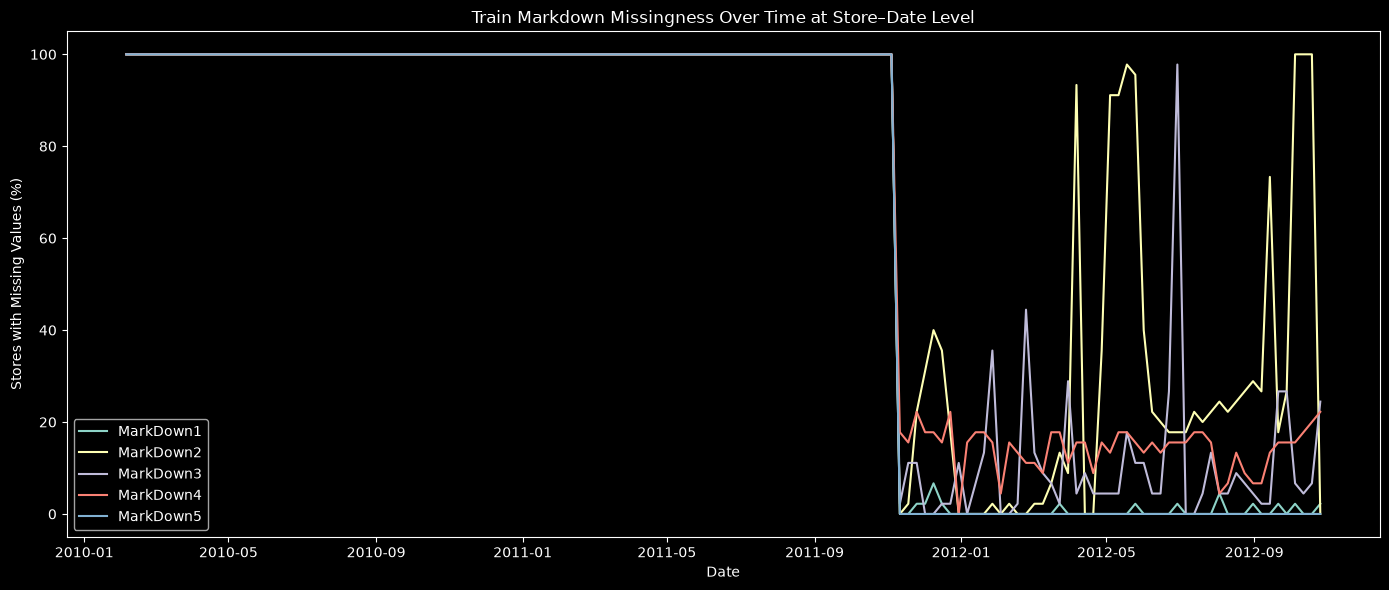

In [16]:
figure, axis = plt.subplots(figsize=(14, 6))

for column in markdown_columns:
    axis.plot(
        train_markdown_missing_by_date.index,
        train_markdown_missing_by_date[column],
        label=column,
    )

axis.set_title(
    "Train Markdown Missingness Over Time at Store–Date Level"
)
axis.set_xlabel("Date")
axis.set_ylabel("Stores with Missing Values (%)")
axis.legend()

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "train_markdown_missingness_over_time.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## CPI and unemployment analysis

In [17]:
train_economic_missing_by_date = missingness_by_date(
    train_economic_store_date,
    economic_columns,
)

test_economic_missing_by_date = missingness_by_date(
    test_economic_store_date,
    economic_columns,
)

In [18]:
train_economic_missing_by_date.max()

CPI             0.0
Unemployment    0.0
dtype: float64

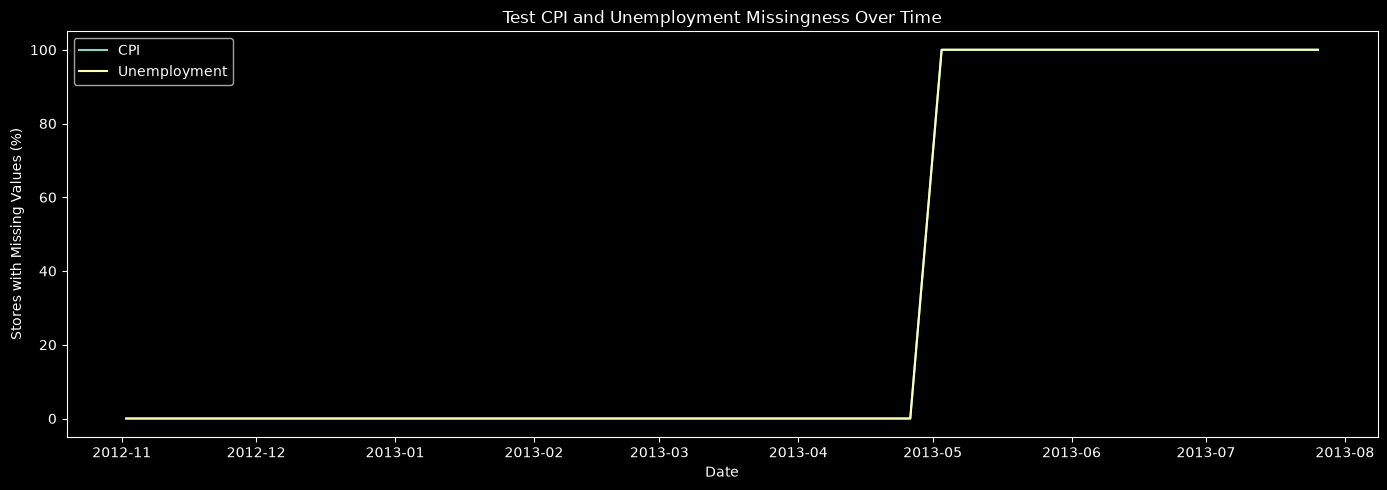

In [19]:
figure, axis = plt.subplots(figsize=(14, 5))

for column in economic_columns:
    axis.plot(
        test_economic_missing_by_date.index,
        test_economic_missing_by_date[column],
        label=column,
    )

axis.set_title(
    "Test CPI and Unemployment Missingness Over Time"
)
axis.set_xlabel("Date")
axis.set_ylabel("Stores with Missing Values (%)")
axis.legend()

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "test_economic_missingness_over_time.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [20]:
missing_economic_dates = (
    test_economic_missing_by_date.index[
        test_economic_missing_by_date
        .gt(0)
        .any(axis=1)
    ]
)

complete_economic_dates = (
    test_economic_missing_by_date.index[
        test_economic_missing_by_date
        .eq(0)
        .all(axis=1)
    ]
)

economic_time_summary = pd.Series(
    {
        "train_max_missing_percent": (
            train_economic_missing_by_date
            .to_numpy()
            .max()
        ),
        "test_last_complete_date": (
            complete_economic_dates.max()
        ),
        "test_first_missing_date": (
            missing_economic_dates.min()
        ),
        "test_missing_dates": len(
            missing_economic_dates
        ),
        "test_total_dates": len(
            test_economic_missing_by_date
        ),
    }
)

economic_time_summary

train_max_missing_percent                    0.0
test_last_complete_date      2013-04-26 00:00:00
test_first_missing_date      2013-05-03 00:00:00
test_missing_dates                            13
test_total_dates                              39
dtype: object

## Target variable analysis

In [21]:
target_summary = train["Weekly_Sales"].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
        0.995,
    ]
)

target_summary

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
1%            5.000000
5%           59.974500
25%        2079.650000
50%        7612.030000
75%       20205.852500
95%       61201.951000
99%      106479.586000
99.5%    130447.869850
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [22]:
target_special_values = pd.Series(
    {
        "negative_count": (
            train["Weekly_Sales"] < 0
        ).sum(),
        "negative_percent": (
            train["Weekly_Sales"] < 0
        ).mean() * 100,
        "zero_count": (
            train["Weekly_Sales"] == 0
        ).sum(),
        "zero_percent": (
            train["Weekly_Sales"] == 0
        ).mean() * 100,
        "positive_count": (
            train["Weekly_Sales"] > 0
        ).sum(),
        "minimum": train["Weekly_Sales"].min(),
        "maximum": train["Weekly_Sales"].max(),
        "mean": train["Weekly_Sales"].mean(),
        "median": train["Weekly_Sales"].median(),
    }
)

target_special_values

negative_count        1285.000000
negative_percent         0.304813
zero_count              73.000000
zero_percent             0.017316
positive_count      420212.000000
minimum              -4988.940000
maximum             693099.360000
mean                 15981.258123
median                7612.030000
dtype: float64

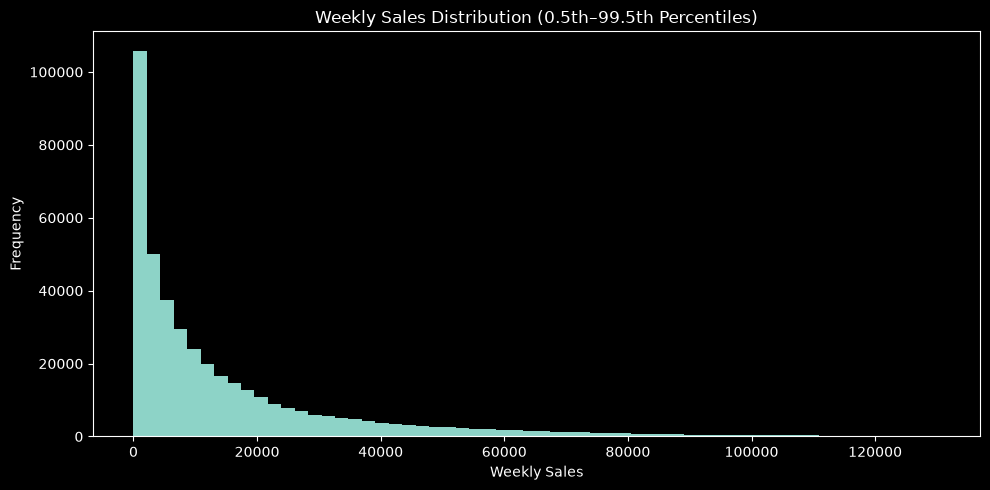

In [23]:
lower_limit = train["Weekly_Sales"].quantile(0.005)
upper_limit = train["Weekly_Sales"].quantile(0.995)

target_for_plot = train.loc[
    train["Weekly_Sales"].between(
        lower_limit,
        upper_limit,
    ),
    "Weekly_Sales",
]

figure, axis = plt.subplots(figsize=(10, 5))

axis.hist(
    target_for_plot,
    bins=60,
)

axis.set_title(
    "Weekly Sales Distribution "
    "(0.5th–99.5th Percentiles)"
)
axis.set_xlabel("Weekly Sales")
axis.set_ylabel("Frequency")

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "weekly_sales_distribution_clipped.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Sales over time

In [24]:
weekly_total_sales = (
    train.groupby("Date", as_index=False)
    .agg(
        total_sales=("Weekly_Sales", "sum"),
        mean_sales=("Weekly_Sales", "mean"),
        median_sales=("Weekly_Sales", "median"),
        active_series=("Weekly_Sales", "count"),
    )
)

weekly_total_sales.head()

,Date,total_sales,mean_sales,median_sales,active_series
0,2010-02-05,49750740.50,16836.121997,7904.690,2955
1,2010-02-12,48336677.63,16352.056032,8365.095,2956
2,2010-02-19,48276993.78,16216.658979,8411.250,2977
3,2010-02-26,43968571.13,14899.549688,7235.800,2951
4,2010-03-05,46871470.30,15921.015727,7717.975,2944


## Holiday effect

In [25]:
weekly_holiday_sales = (
    train.groupby(
        ["Date", "IsHoliday"],
        as_index=False,
    )
    .agg(
        total_sales=("Weekly_Sales", "sum"),
        mean_sales=("Weekly_Sales", "mean"),
        active_series=("Weekly_Sales", "count"),
    )
)

holiday_week_summary = (
    weekly_holiday_sales
    .groupby("IsHoliday")
    .agg(
        weeks=("Date", "nunique"),
        mean_total_sales=("total_sales", "mean"),
        median_total_sales=("total_sales", "median"),
        std_total_sales=("total_sales", "std"),
        maximum_total_sales=("total_sales", "max"),
    )
)

holiday_week_summary

,weeks,mean_total_sales,median_total_sales,std_total_sales,maximum_total_sales
IsHoliday,,,,,
False,133,4.685654e+07,46128514.25,5.083440e+06,80931415.60
True,10,5.052996e+07,47833126.05,8.642457e+06,66593605.26


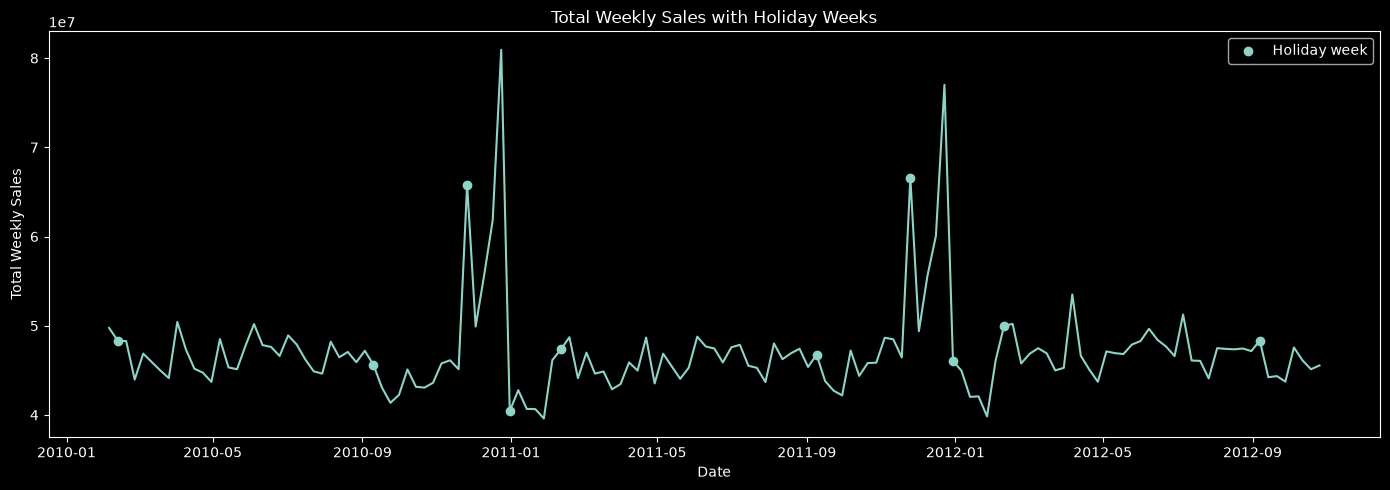

In [26]:
holiday_dates = weekly_holiday_sales.loc[
    weekly_holiday_sales["IsHoliday"],
    "Date",
]

figure, axis = plt.subplots(figsize=(14, 5))

axis.plot(
    weekly_total_sales["Date"],
    weekly_total_sales["total_sales"],
)

holiday_points = weekly_total_sales[
    weekly_total_sales["Date"].isin(
        holiday_dates
    )
]

axis.scatter(
    holiday_points["Date"],
    holiday_points["total_sales"],
    label="Holiday week",
)

axis.set_title(
    "Total Weekly Sales with Holiday Weeks"
)
axis.set_xlabel("Date")
axis.set_ylabel("Total Weekly Sales")
axis.legend()

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "total_sales_with_holiday_weeks.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Store-Department series coverage

In [27]:
series_summary = (
    train.groupby(["Store", "Dept"])
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        observations=("Date", "nunique"),
    )
    .reset_index()
)

series_summary["expected_weeks"] = (
    (
        series_summary["last_date"]
        - series_summary["first_date"]
    ).dt.days // 7
) + 1

series_summary["missing_weeks"] = (
    series_summary["expected_weeks"]
    - series_summary["observations"]
)

series_coverage_summary = pd.Series(
    {
        "number_of_series": len(series_summary),
        "minimum_observations": (
            series_summary["observations"].min()
        ),
        "median_observations": (
            series_summary["observations"].median()
        ),
        "maximum_observations": (
            series_summary["observations"].max()
        ),
        "series_with_internal_gaps": (
            series_summary["missing_weeks"] > 0
        ).sum(),
        "series_with_internal_gaps_percent": (
            series_summary["missing_weeks"] > 0
        ).mean() * 100,
    }
)

series_coverage_summary

number_of_series                     3331.000000
minimum_observations                    1.000000
median_observations                   143.000000
maximum_observations                  143.000000
series_with_internal_gaps             605.000000
series_with_internal_gaps_percent      18.162714
dtype: float64

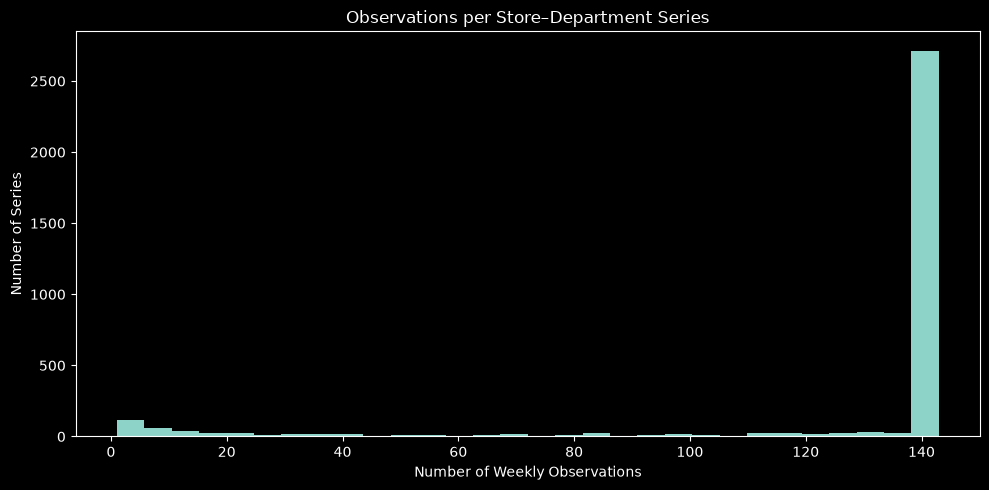

In [28]:
figure, axis = plt.subplots(figsize=(10, 5))

axis.hist(
    series_summary["observations"],
    bins=30,
)

axis.set_title(
    "Observations per Store–Department Series"
)
axis.set_xlabel("Number of Weekly Observations")
axis.set_ylabel("Number of Series")

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "series_length_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Store and department heterogeneity

In [29]:
store_weekly_sales = (
    train.groupby(
        ["Store", "Type", "Date"],
        as_index=False,
    )
    .agg(
        store_total_sales=(
            "Weekly_Sales",
            "sum",
        )
    )
)

store_type_summary = (
    store_weekly_sales
    .groupby("Type")
    .agg(
        stores=("Store", "nunique"),
        store_weeks=("Date", "count"),
        mean_weekly_store_sales=(
            "store_total_sales",
            "mean",
        ),
        median_weekly_store_sales=(
            "store_total_sales",
            "median",
        ),
        standard_deviation=(
            "store_total_sales",
            "std",
        ),
    )
    .sort_values(
        "mean_weekly_store_sales",
        ascending=False,
    )
)

store_type_summary

,stores,store_weeks,mean_weekly_store_sales,median_weekly_store_sales,standard_deviation
Type,,,,,
A,22,3146,1.376673e+06,1370656.475,530879.287452
B,17,2431,8.229950e+05,733037.320,407994.164932
C,6,858,4.726148e+05,477818.775,115618.943705


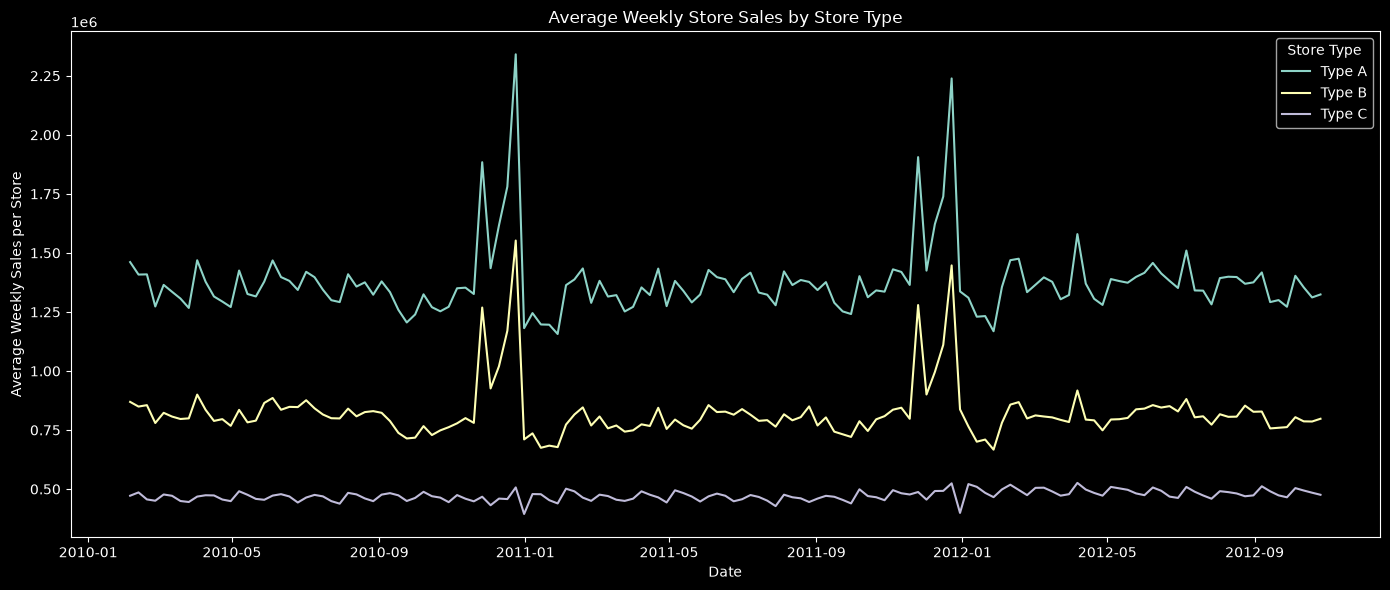

In [30]:
store_type_over_time = (
    store_weekly_sales
    .groupby(
        ["Type", "Date"],
        as_index=False,
    )
    .agg(
        average_weekly_store_sales=(
            "store_total_sales",
            "mean",
        )
    )
)

figure, axis = plt.subplots(figsize=(14, 6))

for store_type, group in store_type_over_time.groupby("Type"):
    axis.plot(
        group["Date"],
        group["average_weekly_store_sales"],
        label=f"Type {store_type}",
    )

axis.set_title(
    "Average Weekly Store Sales by Store Type"
)
axis.set_xlabel("Date")
axis.set_ylabel("Average Weekly Sales per Store")
axis.legend(title="Store Type")

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "weekly_store_sales_by_type.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [31]:
department_summary = (
    train.groupby("Dept")["Weekly_Sales"]
    .agg(
        observations="count",
        mean_sales="mean",
        median_sales="median",
        total_sales="sum",
        standard_deviation="std",
    )
    .sort_values(
        "total_sales",
        ascending=False,
    )
)

department_summary.head(15)

,observations,mean_sales,median_sales,total_sales,standard_deviation
Dept,,,,,
92,6435,75204.870531,61816.77,4.839433e+08,49413.732570
95,6435,69824.423080,60774.39,4.493202e+08,38200.536452
38,6435,61090.619568,57336.65,3.931181e+08,23966.913901
72,6046,50566.515417,44312.36,3.057252e+08,44710.982652
90,6435,45232.084488,40535.79,2.910685e+08,32462.020077
40,6435,44900.702727,42717.87,2.889360e+08,21903.876911
2,6435,43607.020113,41412.61,2.806112e+08,25176.756920
91,6435,33687.910758,31033.63,2.167817e+08,26247.462296
13,6435,30663.802634,27970.82,1.973216e+08,16237.526432


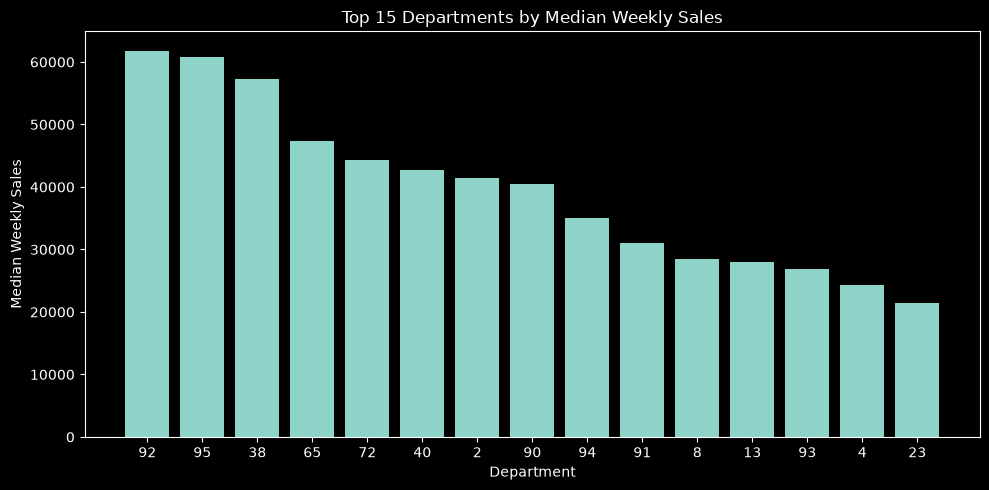

In [32]:
top_departments = (
    department_summary
    .sort_values(
        "median_sales",
        ascending=False,
    )
    .head(15)
)

figure, axis = plt.subplots(figsize=(10, 5))

axis.bar(
    top_departments.index.astype(str),
    top_departments["median_sales"],
)

axis.set_title(
    "Top 15 Departments by Median Weekly Sales"
)
axis.set_xlabel("Department")
axis.set_ylabel("Median Weekly Sales")

figure.tight_layout()
plt.show()

## Train-test compatibility

In [33]:
train_stores = set(train["Store"].unique())
test_stores = set(test["Store"].unique())

train_departments = set(
    train["Dept"].unique()
)
test_departments = set(
    test["Dept"].unique()
)

train_pairs = set(
    map(
        tuple,
        train[["Store", "Dept"]]
        .drop_duplicates()
        .to_numpy(),
    )
)

test_pairs = set(
    map(
        tuple,
        test[["Store", "Dept"]]
        .drop_duplicates()
        .to_numpy(),
    )
)

entity_comparison = pd.Series(
    {
        "unseen_test_stores": len(
            test_stores - train_stores
        ),
        "unseen_test_departments": len(
            test_departments
            - train_departments
        ),
        "unseen_test_store_department_pairs": len(
            test_pairs - train_pairs
        ),
        "train_only_store_department_pairs": len(
            train_pairs - test_pairs
        ),
    }
)

entity_comparison

unseen_test_stores                      0
unseen_test_departments                 0
unseen_test_store_department_pairs     11
train_only_store_department_pairs     173
dtype: int64

In [34]:
split_train_pairs = set(
    map(
        tuple,
        split.train[
            ["Store", "Dept"]
        ]
        .drop_duplicates()
        .to_numpy(),
    )
)

validation_pairs = set(
    map(
        tuple,
        split.validation[
            ["Store", "Dept"]
        ]
        .drop_duplicates()
        .to_numpy(),
    )
)

unseen_validation_pairs = (
    validation_pairs - split_train_pairs
)

validation_summary = pd.Series(
    {
        "training_start": (
            split.train["Date"].min()
        ),
        "training_end": (
            split.train["Date"].max()
        ),
        "validation_start": (
            split.validation_start
        ),
        "validation_end": (
            split.validation_end
        ),
        "validation_weeks": (
            split.validation_weeks
        ),
        "training_rows": len(split.train),
        "validation_rows": len(
            split.validation
        ),
        "validation_holiday_weeks": (
            split.validation.loc[
                split.validation["IsHoliday"],
                "Date",
            ].nunique()
        ),
        "unseen_validation_pairs": len(
            unseen_validation_pairs
        ),
    }
)

validation_summary

training_start              2010-02-05 00:00:00
training_end                2012-01-27 00:00:00
validation_start            2012-02-03 00:00:00
validation_end              2012-10-26 00:00:00
validation_weeks                             39
training_rows                            305982
validation_rows                          115588
validation_holiday_weeks                      2
unseen_validation_pairs                      25
dtype: object

## Seasonality

In [35]:
seasonality = weekly_total_sales.copy()

seasonality["week_of_year"] = (
    seasonality["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

weekly_seasonality = (
    seasonality
    .groupby(
        "week_of_year",
        as_index=False,
    )
    .agg(
        average_total_sales=(
            "total_sales",
            "mean",
        )
    )
)

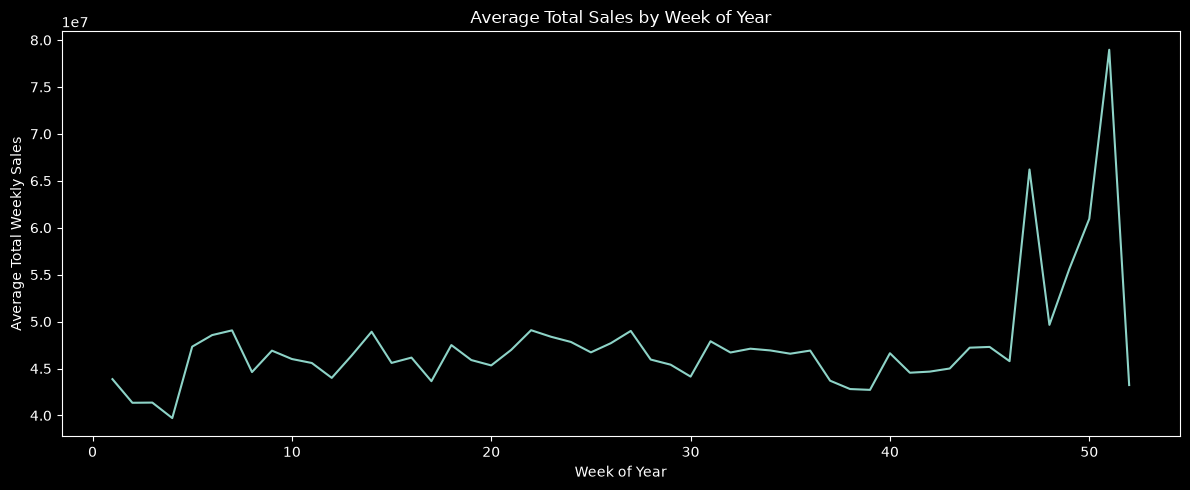

In [36]:
figure, axis = plt.subplots(figsize=(12, 5))

axis.plot(
    weekly_seasonality["week_of_year"],
    weekly_seasonality["average_total_sales"],
)

axis.set_title(
    "Average Total Sales by Week of Year"
)
axis.set_xlabel("Week of Year")
axis.set_ylabel("Average Total Weekly Sales")

figure.tight_layout()

figure.savefig(
    FIGURES_DIR / "average_sales_by_week_of_year.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()